## Spotify Song Popularity Analysis and Web Scraping Project

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Spotify Dataset.csv to Spotify Dataset (1).csv


### Upload Dataset
This cell handles the uploading of the `Spotify Dataset.csv` file from your local machine to the Colab environment.

In [ ]:
import os

os.listdir("/content")

['.config', 'Spotify Dataset (1).csv', '.ipynb_checkpoints', 'sample_data']

### Verify Uploaded Files
This cell lists the contents of the current directory to confirm that the dataset has been successfully uploaded.

In [ ]:
import pandas as pd

df = pd.read_csv("/content/Spotify Dataset (1).csv")
df.head()

,Song,Artist,Genre,Year,Streams,In Spotify Playlists,On Spotify Charts,Billboard Rankings,In Apple Playlists,On Apple Charts,...,Decibel,Mode,Energy,Danceability,Liveness,Valence,Duration,Acousticness,Speechiness,Popularity
0,3,Britney Spears,Dance Pop,2010,339473453,2612,258,192,32497,69,...,-2,Major,71,70,14,79,213,5,5,62
1,43776,Beyoncé,Dance Pop,2015,665765558,5415,396,31,29766,31,...,-5,Major,71,75,13,56,214,1,13,72
2,#Beautiful,Mariah Carey,Dance Pop,2013,245400167,1796,317,12,37077,12,...,-5,Major,76,68,31,45,200,29,4,51
3,#SELFIE,The Chainsmokers,Electropop,2014,382199619,2988,331,109,3762,109,...,-3,Major,92,79,8,66,184,1,25,65
4,#thatPOWER,will.i.am,Dance Pop,2013,473248298,3741,444,101,38461,101,...,-6,Minor,61,80,7,40,280,0,6,68


### Load and Preview Dataset
This cell loads the Spotify dataset into a Pandas DataFrame and displays the first few rows to give an initial glimpse of the data structure and content.

In [ ]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 10 records:")
display(df.head(10))

print("\nDataset details:")
df.info()

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Dataset shape: (599, 25)

Column names:
['Song', 'Artist', 'Genre', 'Year', 'Streams', 'In Spotify Playlists', 'On Spotify Charts', 'Billboard Rankings', 'In Apple Playlists', 'On Apple Charts', 'In Deezer Playlists', 'In Deezer Charts', 'In YouTube Playlists', 'On Shazam Charts', 'Bpm', 'Decibel', 'Mode', 'Energy', 'Danceability', 'Liveness', 'Valence', 'Duration', 'Acousticness', 'Speechiness', 'Popularity']

First 10 records:


,Song,Artist,Genre,Year,Streams,In Spotify Playlists,On Spotify Charts,Billboard Rankings,In Apple Playlists,On Apple Charts,...,Decibel,Mode,Energy,Danceability,Liveness,Valence,Duration,Acousticness,Speechiness,Popularity
0,3,Britney Spears,Dance Pop,2010,339473453,2612,258,192,32497,69,...,-2,Major,71,70,14,79,213,5,5,62
1,43776,Beyoncé,Dance Pop,2015,665765558,5415,396,31,29766,31,...,-5,Major,71,75,13,56,214,1,13,72
2,#Beautiful,Mariah Carey,Dance Pop,2013,245400167,1796,317,12,37077,12,...,-5,Major,76,68,31,45,200,29,4,51
3,#SELFIE,The Chainsmokers,Electropop,2014,382199619,2988,331,109,3762,109,...,-3,Major,92,79,8,66,184,1,25,65
4,#thatPOWER,will.i.am,Dance Pop,2013,473248298,3741,444,101,38461,101,...,-6,Minor,61,80,7,40,280,0,6,68
5,...Ready For It? - BloodPop® Remix,Taylor Swift,Pop,2018,246127838,1800,274,6,5969,6,...,-5,Major,84,58,10,50,190,13,22,85
6,1+1,Beyoncé,Dance Pop,2011,311482393,2442,326,283,2868,55,...,-7,Minor,38,30,7,26,274,38,3,60
7,24K Magic,Bruno Mars,Pop,2017,496311364,3983,421,12,31539,12,...,-4,Major,80,82,15,63,226,3,8,85
8,2U (feat. Justin Bieber),David Guetta,Dance Pop,2018,367814306,2915,197,19,34663,19,...,-7,Minor,61,53,23,53,195,23,6,65
9,7 Years,Lukas Graham,Danish Pop,2016,1440757818,15894,27,38,19993,89,...,-6,Minor,47,77,39,34,237,29,5,80



Dataset details:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 599 entries, 0 to 598
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Song                  599 non-null    object
 1   Artist                599 non-null    object
 2   Genre                 599 non-null    object
 3   Year                  599 non-null    int64 
 4   Streams               599 non-null    int64 
 5   In Spotify Playlists  599 non-null    int64 
 6   On Spotify Charts     599 non-null    int64 
 7   Billboard Rankings    599 non-null    int64 
 8   In Apple Playlists    599 non-null    int64 
 9   On Apple Charts       599 non-null    int64 
 10  In Deezer Playlists   599 non-null    object
 11  In Deezer Charts      599 non-null    int64 
 12  In YouTube Playlists  599 non-null    int64 
 13  On Shazam Charts      599 non-null    int64 
 14  Bpm                   599 non-null    int64 
 15  Decibel               

### Initial Data Inspection
This cell performs a comprehensive initial inspection of the dataset, including its shape, column names, data types, and checks for missing values and duplicate rows. This helps in understanding the dataset's integrity and structure.

In [ ]:
for col in df.columns:
    print(f"\n--- {col} ---")
    print(df[col].dropna().head(5).tolist())


--- Song ---
['3', '43776', '#Beautiful', '#SELFIE', '#thatPOWER']

--- Artist ---
['Britney Spears', 'Beyoncé', 'Mariah Carey', 'The Chainsmokers', 'will.i.am']

--- Genre ---
['Dance Pop', 'Dance Pop', 'Dance Pop', 'Electropop', 'Dance Pop']

--- Year ---
[2010, 2015, 2013, 2014, 2013]

--- Streams ---
[339473453, 665765558, 245400167, 382199619, 473248298]

--- In Spotify Playlists ---
[2612, 5415, 1796, 2988, 3741]

--- On Spotify Charts ---
[258, 396, 317, 331, 444]

--- Billboard Rankings ---
[192, 31, 12, 109, 101]

--- In Apple Playlists ---
[32497, 29766, 37077, 3762, 38461]

--- On Apple Charts ---
[69, 31, 12, 109, 101]

--- In Deezer Playlists ---
['7444', '1', '10', '305', '1397']

--- In Deezer Charts ---
[164, 34, 33, 3, 4]

--- In YouTube Playlists ---
[5718, 17576, 15160, 38113, 23843]

--- On Shazam Charts ---
[127, 168, 319, 149, 320]

--- Bpm ---
[135, 136, 107, 128, 128]

--- Decibel ---
[-2, -5, -5, -3, -6]

--- Mode ---
['Major', 'Major', 'Major', 'Major', 'Mino

### Preview Column Data
This cell iterates through each column of the DataFrame and prints the first 5 non-null values, providing a quick overview of the data format within each column.

In [8]:
import pandas as pd
import numpy as np

print("Shape before cleaning:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Shape before cleaning: (599, 25)

Data types:
Song                    object
Artist                  object
Genre                   object
Year                     int64
Streams                  int64
In Spotify Playlists     int64
On Spotify Charts        int64
Billboard Rankings       int64
In Apple Playlists       int64
On Apple Charts          int64
In Deezer Playlists     object
In Deezer Charts         int64
In YouTube Playlists     int64
On Shazam Charts         int64
Bpm                      int64
Decibel                  int64
Mode                    object
Energy                   int64
Danceability             int64
Liveness                 int64
Valence                  int64
Duration                 int64
Acousticness             int64
Speechiness              int64
Popularity               int64
dtype: object

Missing values:
Song                    0
Artist                  0
Genre                   0
Year                    0
Streams                 0
In Spotify Playlis

### Pre-Cleaning Data Overview
This cell provides a pre-cleaning overview of the dataset's shape, data types, missing values, and duplicate rows. It serves as a checkpoint to compare with post-cleaning statistics.

In [9]:
import pandas as pd
import numpy as np

data = df.copy()

data["In Deezer Playlists"] = pd.to_numeric(
    data["In Deezer Playlists"],
    errors="coerce"
)

print("Missing values after conversion:")
print(data.isnull().sum())

data["In Deezer Playlists"] = data["In Deezer Playlists"].fillna(
    data["In Deezer Playlists"].median()
)

print("\nCleaned dataset shape:", data.shape)

print("\nData types after conversion:")
print(data.dtypes)

display(data.head())

Missing values after conversion:
Song                     0
Artist                   0
Genre                    0
Year                     0
Streams                  0
In Spotify Playlists     0
On Spotify Charts        0
Billboard Rankings       0
In Apple Playlists       0
On Apple Charts          0
In Deezer Playlists     49
In Deezer Charts         0
In YouTube Playlists     0
On Shazam Charts         0
Bpm                      0
Decibel                  0
Mode                     0
Energy                   0
Danceability             0
Liveness                 0
Valence                  0
Duration                 0
Acousticness             0
Speechiness              0
Popularity               0
dtype: int64

Cleaned dataset shape: (599, 25)

Data types after conversion:
Song                     object
Artist                   object
Genre                    object
Year                      int64
Streams                   int64
In Spotify Playlists      int64
On Spotify Charts      

,Song,Artist,Genre,Year,Streams,In Spotify Playlists,On Spotify Charts,Billboard Rankings,In Apple Playlists,On Apple Charts,...,Decibel,Mode,Energy,Danceability,Liveness,Valence,Duration,Acousticness,Speechiness,Popularity
0,3,Britney Spears,Dance Pop,2010,339473453,2612,258,192,32497,69,...,-2,Major,71,70,14,79,213,5,5,62
1,43776,Beyoncé,Dance Pop,2015,665765558,5415,396,31,29766,31,...,-5,Major,71,75,13,56,214,1,13,72
2,#Beautiful,Mariah Carey,Dance Pop,2013,245400167,1796,317,12,37077,12,...,-5,Major,76,68,31,45,200,29,4,51
3,#SELFIE,The Chainsmokers,Electropop,2014,382199619,2988,331,109,3762,109,...,-3,Major,92,79,8,66,184,1,25,65
4,#thatPOWER,will.i.am,Dance Pop,2013,473248298,3741,444,101,38461,101,...,-6,Minor,61,80,7,40,280,0,6,68


### Data Cleaning: Handling 'In Deezer Playlists' Column
This cell cleans the 'In Deezer Playlists' column by converting it to a numeric type, coercing errors to NaN, and then filling the missing values with the median of the column. This ensures the column is in a suitable format for numerical analysis.

In [10]:
print(data["In Deezer Playlists"].describe())

count     599.000000
mean     1347.780467
std      2596.837662
min         1.000000
25%        20.500000
50%        86.500000
75%       710.000000
max      9944.000000
Name: In Deezer Playlists, dtype: float64


### Verify 'In Deezer Playlists' After Cleaning
This cell displays descriptive statistics for the 'In Deezer Playlists' column after cleaning, confirming that the data type conversion and missing value imputation were successful.

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

### Setup Visualization Theme
This cell sets the aesthetic theme for all subsequent plots using Seaborn, ensuring a consistent and visually appealing style.

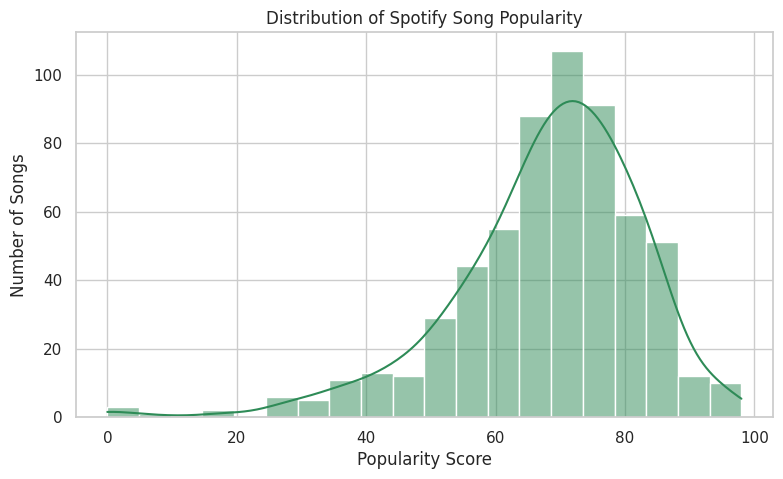

In [12]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=data,
    x="Popularity",
    bins=20,
    kde=True,
    color="seagreen"
)

plt.title("Distribution of Spotify Song Popularity")
plt.xlabel("Popularity Score")
plt.ylabel("Number of Songs")
plt.show()

### Distribution of Song Popularity
This cell generates a histogram to visualize the distribution of the 'Popularity' score, providing insights into how song popularity is spread across the dataset.

In [13]:
top_10 = data.sort_values(
    "Popularity",
    ascending=False
)[["Song", "Artist", "Genre", "Year", "Popularity", "Streams"]].head(10)

display(top_10)

,Song,Artist,Genre,Year,Popularity,Streams
449,Someone Like You,Adele,British Soul,2011,98,3743895074
450,Someone You Loved,Lewis Capaldi,Pop,2019,96,2887241814
292,Locked Out of Heaven,Bruno Mars,Pop,2012,96,1367810478
251,It Will Rain,Bruno Mars,Pop,2012,96,217672943
306,Love Somebody,Maroon 5,Pop,2013,96,387570742
430,Señorita,Shawn Mendes,Canadian Pop,2019,95,2864791672
317,Maps,Maroon 5,Pop,2014,94,1230675890
321,Marry You,Bruno Mars,Pop,2011,94,751134527
320,Marry You,Bruno Mars,Pop,2010,94,777765388
325,Memories,Maroon 5,Pop,2019,94,2838096550


### Identify Top 10 Most Popular Songs
This cell identifies and displays the top 10 most popular songs based on their 'Popularity' score, along with relevant details like artist, genre, year, and streams.

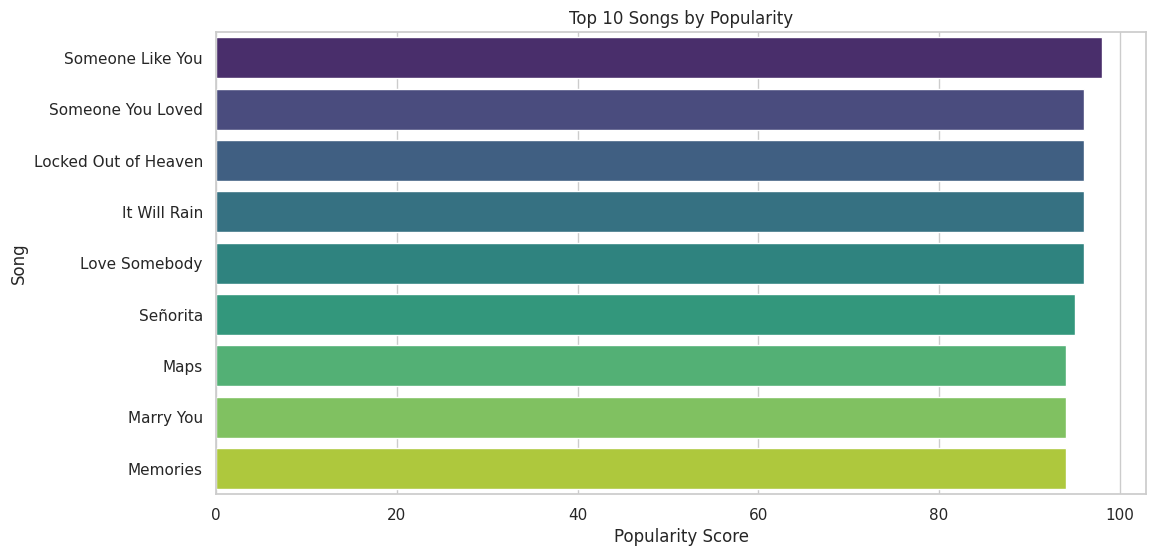

In [14]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_10,
    x="Popularity",
    y="Song",
    hue="Song",
    palette="viridis",
    legend=False
)

plt.title("Top 10 Songs by Popularity")
plt.xlabel("Popularity Score")
plt.ylabel("Song")
plt.show()

### Visualize Top 10 Popular Songs
This cell creates a bar plot to visually represent the top 10 most popular songs, making it easy to compare their popularity scores.

In [15]:
genre_count = (
    data["Genre"]
    .value_counts()
    .head(15)
    .reset_index()
)

genre_count.columns = ["Genre", "Song Count"]

display(genre_count)

,Genre,Song Count
0,Dance Pop,325
1,Pop,62
2,Canadian Pop,34
3,Barbadian Pop,15
4,Boy Band,15
5,Electropop,13
6,British Soul,11
7,Hip Hop,10
8,Neo Mellow,9
9,Big Room,9


### Count Songs by Genre
This cell counts the number of songs for each genre and displays the top 15 genres, providing an overview of the genre distribution in the dataset.

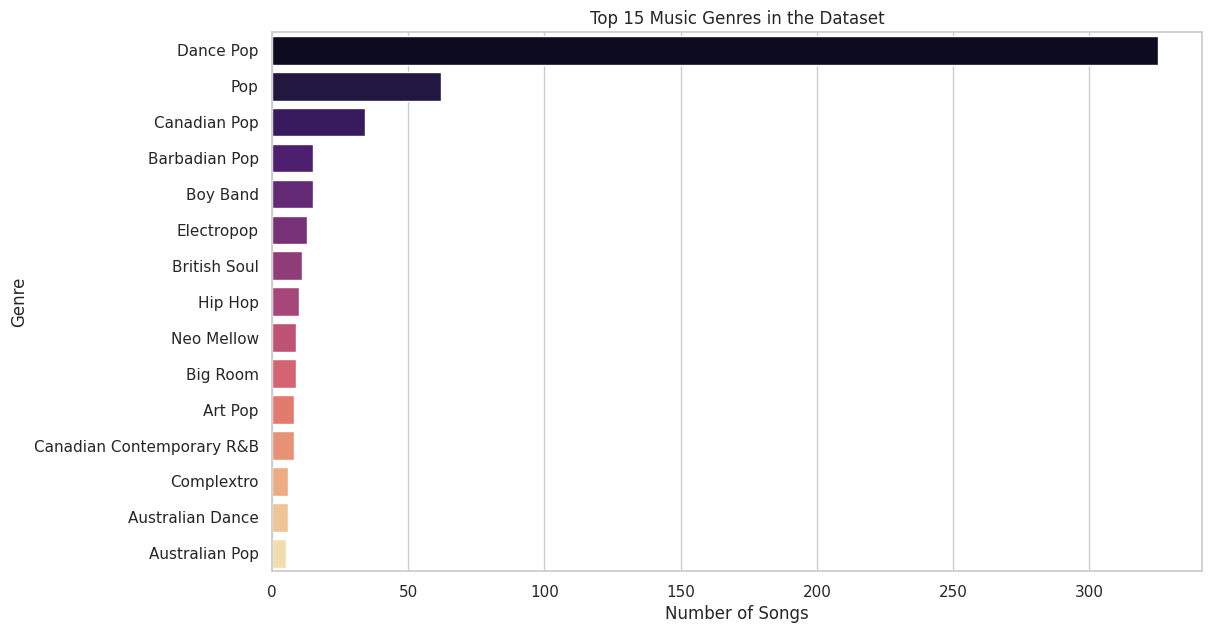

In [16]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=genre_count,
    x="Song Count",
    y="Genre",
    hue="Genre",
    palette="magma",
    legend=False
)

plt.title("Top 15 Music Genres in the Dataset")
plt.xlabel("Number of Songs")
plt.ylabel("Genre")
plt.show()

### Visualize Top 15 Music Genres
This cell generates a bar plot showing the top 15 music genres by song count, offering a visual representation of genre prevalence.

In [17]:
genre_summary = (
    data.groupby("Genre")
    .agg(
        Average_Popularity=("Popularity", "mean"),
        Song_Count=("Song", "count")
    )
    .reset_index()
)

genre_summary = genre_summary[
    genre_summary["Song_Count"] >= 5
].sort_values(
    "Average_Popularity",
    ascending=False
)

display(genre_summary.head(15))

,Genre,Average_Popularity,Song_Count
45,Pop,81.854839,62
28,EDM,78.200000,5
32,Electropop,77.461538,13
14,Canadian Contemporary R&B,76.875000,8
11,Big Room,72.888889,9
17,Canadian Pop,71.676471,34
13,British Soul,71.636364,11
12,Boy Band,69.666667,15
35,Hip Hop,67.500000,10
22,Complextro,67.333333,6


### Analyze Average Popularity by Genre
This cell groups the data by genre and calculates the average popularity for genres with at least 5 songs, then displays the top 15 genres by average popularity. This helps identify genres that tend to produce more popular songs.

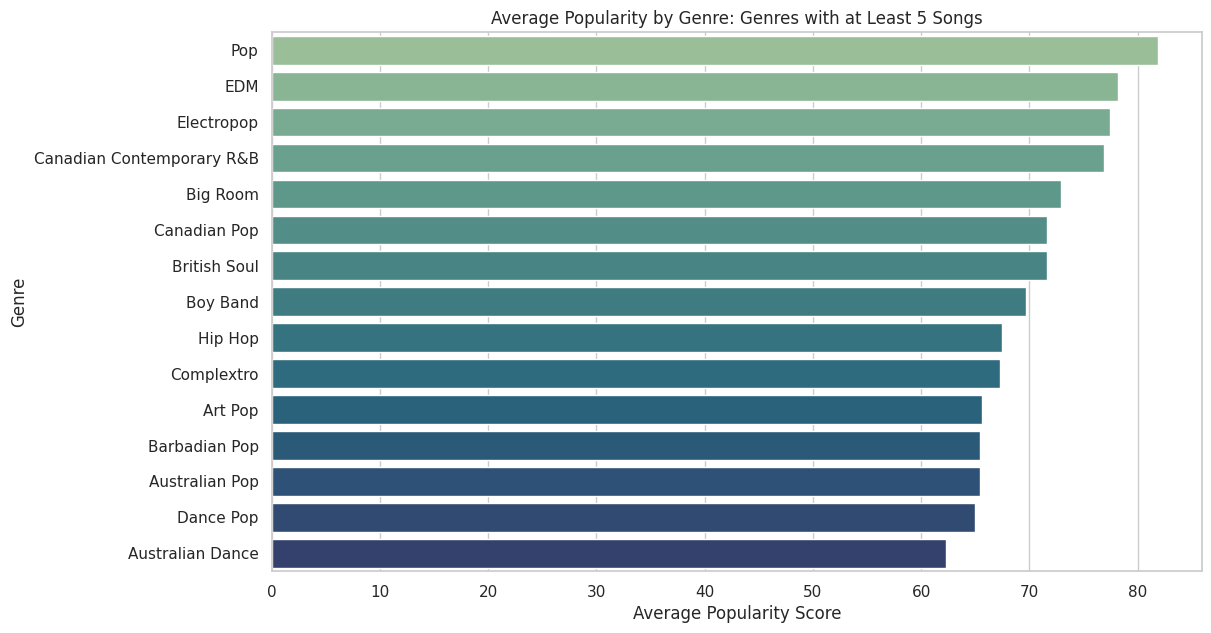

In [18]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=genre_summary.head(15),
    x="Average_Popularity",
    y="Genre",
    hue="Genre",
    palette="crest",
    legend=False
)

plt.title("Average Popularity by Genre: Genres with at Least 5 Songs")
plt.xlabel("Average Popularity Score")
plt.ylabel("Genre")
plt.show()

### Visualize Average Popularity by Genre
This cell creates a bar plot to visualize the average popularity scores of the top 15 genres, providing insights into which genres perform best in terms of popularity.

In [19]:
numeric_features = [
    "Year",
    "Streams",
    "In Spotify Playlists",
    "On Spotify Charts",
    "Billboard Rankings",
    "In Apple Playlists",
    "On Apple Charts",
    "In Deezer Playlists",
    "In Deezer Charts",
    "In YouTube Playlists",
    "On Shazam Charts",
    "Bpm",
    "Decibel",
    "Energy",
    "Danceability",
    "Liveness",
    "Valence",
    "Duration",
    "Acousticness",
    "Speechiness",
    "Popularity"
]

### Define Numeric Features for Correlation Analysis
This cell defines a list of numeric features that will be used for correlation analysis with the 'Popularity' score.

In [20]:
popularity_correlation = (
    data[numeric_features]
    .corr()["Popularity"]
    .sort_values(ascending=False)
)

print(popularity_correlation)

Popularity              1.000000
Streams                 0.685391
In Spotify Playlists    0.600711
Year                    0.201248
On Apple Charts         0.068525
In YouTube Playlists    0.064067
Danceability            0.060925
Acousticness            0.029061
Valence                 0.018906
Decibel                 0.002503
Bpm                    -0.008098
Billboard Rankings     -0.011312
In Deezer Charts       -0.035600
On Shazam Charts       -0.046079
In Deezer Playlists    -0.055118
Energy                 -0.065804
Speechiness            -0.067547
In Apple Playlists     -0.079135
Liveness               -0.088590
Duration               -0.106169
On Spotify Charts      -0.444862
Name: Popularity, dtype: float64


### Calculate Feature Correlation with Popularity
This cell calculates the Pearson correlation coefficient between all numeric features and the 'Popularity' score, then sorts them in descending order to identify the most influential features.

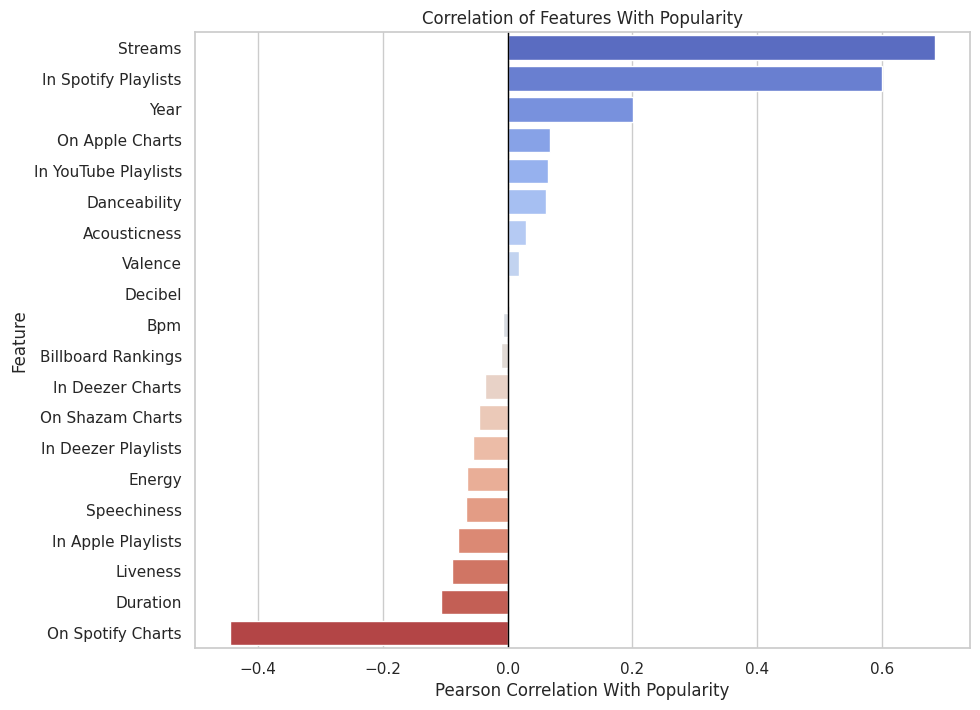

In [21]:
correlation_table = (
    popularity_correlation
    .drop("Popularity")
    .reset_index()
)

correlation_table.columns = ["Feature", "Correlation"]

plt.figure(figsize=(10, 8))

sns.barplot(
    data=correlation_table,
    x="Correlation",
    y="Feature",
    hue="Feature",
    palette="coolwarm",
    legend=False
)

plt.axvline(0, color="black", linewidth=1)
plt.title("Correlation of Features With Popularity")
plt.xlabel("Pearson Correlation With Popularity")
plt.ylabel("Feature")
plt.show()

### Visualize Feature Correlation with Popularity
This cell generates a bar plot to visually represent the correlation of each feature with the 'Popularity' score, making it easy to see positive and negative relationships.

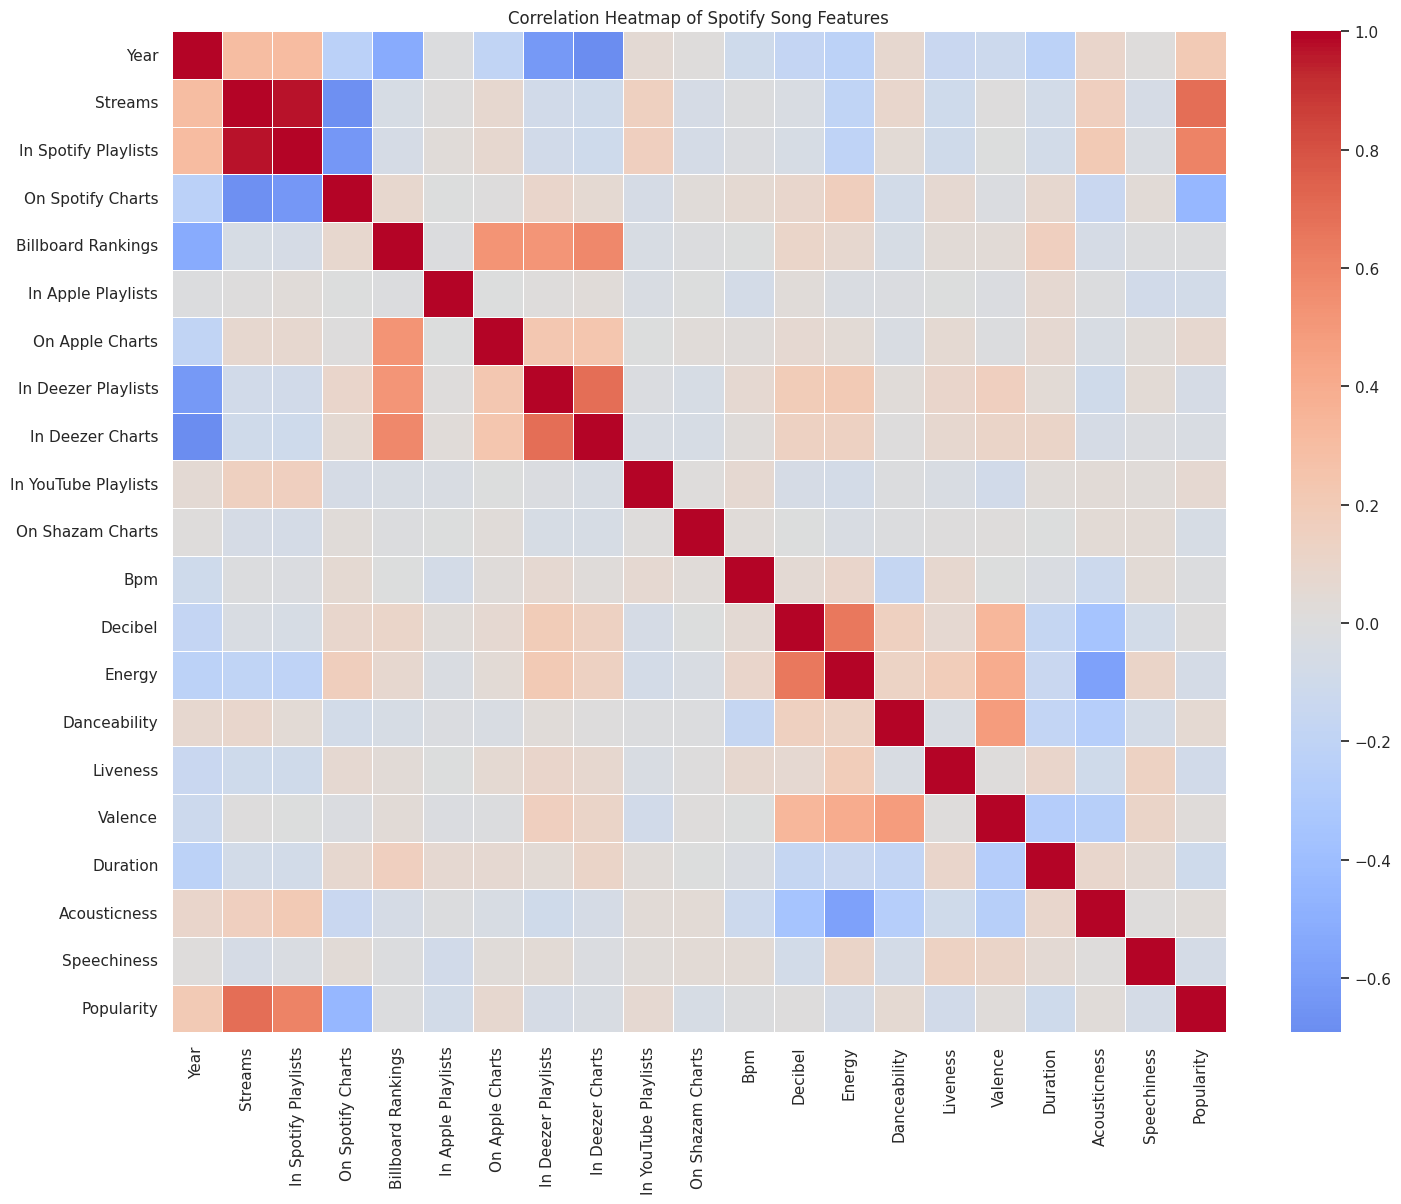

In [22]:
plt.figure(figsize=(17, 13))

sns.heatmap(
    data[numeric_features].corr(),
    cmap="coolwarm",
    center=0,
    linewidths=0.4,
    linecolor="white"
)

plt.title("Correlation Heatmap of Spotify Song Features")
plt.show()

### Visualize Full Feature Correlation Matrix
This cell creates a heatmap of the correlation matrix for all numeric features, providing a comprehensive view of the relationships between all variables in the dataset.

In [23]:
audio_features = [
    "Bpm",
    "Decibel",
    "Energy",
    "Danceability",
    "Liveness",
    "Valence",
    "Duration",
    "Acousticness",
    "Speechiness"
]

X_audio = data[audio_features]
y = data["Popularity"]

print("Audio feature matrix:", X_audio.shape)
print("Target vector:", y.shape)

Audio feature matrix: (599, 9)
Target vector: (599,)


### Prepare Data for Audio-Only Popularity Model
This cell defines the audio-specific features, extracts them into `X_audio`, and sets 'Popularity' as the target variable `y`, preparing the data for the audio-only prediction model.

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X_audio,
    y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 479
Testing rows: 120


### Split Data into Training and Testing Sets (Audio Only)
This cell splits the audio features and popularity target into training and testing sets using `train_test_split`, ensuring proper evaluation of the model's performance on unseen data.

In [ ]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(
    mean_squared_error(y_test, linear_predictions)
)
linear_r2 = r2_score(y_test, linear_predictions)

print(f"Linear Regression MAE: {linear_mae:.2f}")
print(f"Linear Regression RMSE: {linear_rmse:.2f}")
print(f"Linear Regression R²: {linear_r2:.4f}")

In [25]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(
    mean_squared_error(y_test, linear_predictions)
)
linear_r2 = r2_score(y_test, linear_predictions)

print(f"Linear Regression MAE: {linear_mae:.2f}")
print(f"Linear Regression RMSE: {linear_rmse:.2f}")
print(f"Linear Regression R²: {linear_r2:.4f}")

Linear Regression MAE: 11.23
Linear Regression RMSE: 14.95
Linear Regression R²: -0.0219


### Train and Evaluate Linear Regression Model (Audio Only)
This cell trains a Linear Regression model using only audio features and evaluates its performance using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R-squared (R²) metrics.

In [26]:
rf_audio_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_audio_model.fit(X_train, y_train)

rf_audio_predictions = rf_audio_model.predict(X_test)

rf_audio_mae = mean_absolute_error(y_test, rf_audio_predictions)
rf_audio_rmse = np.sqrt(
    mean_squared_error(y_test, rf_audio_predictions)
)
rf_audio_r2 = r2_score(y_test, rf_audio_predictions)

print(f"Random Forest MAE: {rf_audio_mae:.2f}")
print(f"Random Forest RMSE: {rf_audio_rmse:.2f}")
print(f"Random Forest R²: {rf_audio_r2:.4f}")

Random Forest MAE: 10.94
Random Forest RMSE: 14.74
Random Forest R²: 0.0074


### Train and Evaluate Random Forest Model (Audio Only)
This cell trains a Random Forest Regressor model using audio features and evaluates its performance using MAE, RMSE, and R² metrics.

In [27]:
audio_model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression (Audio Only)",
        "Random Forest (Audio Only)"
    ],
    "MAE": [linear_mae, rf_audio_mae],
    "RMSE": [linear_rmse, rf_audio_rmse],
    "R2 Score": [linear_r2, rf_audio_r2]
})

display(audio_model_comparison)

,Model,MAE,RMSE,R2 Score
0,Linear Regression (Audio Only),11.23434,14.953943,-0.021917
1,Random Forest (Audio Only),10.94178,14.737699,0.007424


### Compare Audio-Only Model Performance
This cell creates a DataFrame to compare the performance metrics (MAE, RMSE, R²) of the Linear Regression and Random Forest models trained with only audio features.

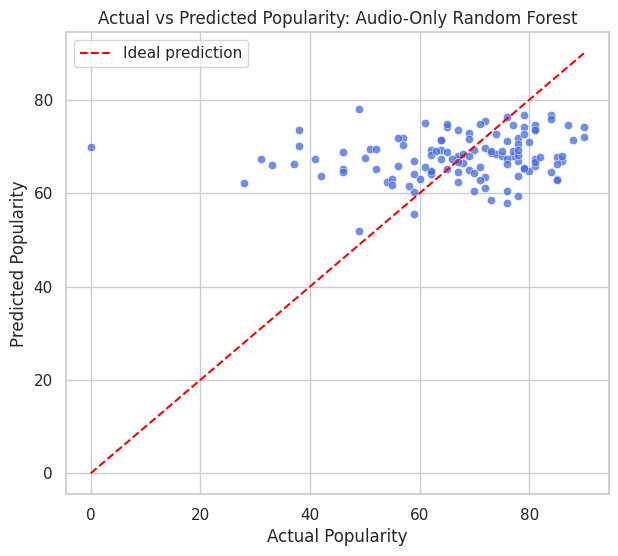

In [28]:
plt.figure(figsize=(7, 6))

sns.scatterplot(
    x=y_test,
    y=rf_audio_predictions,
    color="royalblue",
    alpha=0.75
)

min_value = min(y_test.min(), rf_audio_predictions.min())
max_value = max(y_test.max(), rf_audio_predictions.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    color="red",
    linestyle="--",
    label="Ideal prediction"
)

plt.title("Actual vs Predicted Popularity: Audio-Only Random Forest")
plt.xlabel("Actual Popularity")
plt.ylabel("Predicted Popularity")
plt.legend()
plt.show()

### Visualize Audio-Only Random Forest Predictions
This cell generates a scatter plot comparing the actual popularity values against the predicted popularity values from the Random Forest model trained on audio features, along with an ideal prediction line.

In [29]:
audio_feature_importance = pd.DataFrame({
    "Feature": audio_features,
    "Importance": rf_audio_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

display(audio_feature_importance)

,Feature,Importance
6,Duration,0.144959
2,Energy,0.129130
7,Acousticness,0.128978
5,Valence,0.124700
0,Bpm,0.115149
3,Danceability,0.113167
4,Liveness,0.098816
8,Speechiness,0.077420
1,Decibel,0.067681


### Calculate Audio Feature Importance
This cell calculates and displays the feature importance for the Random Forest model trained on audio features, indicating which audio characteristics are most influential in predicting popularity.

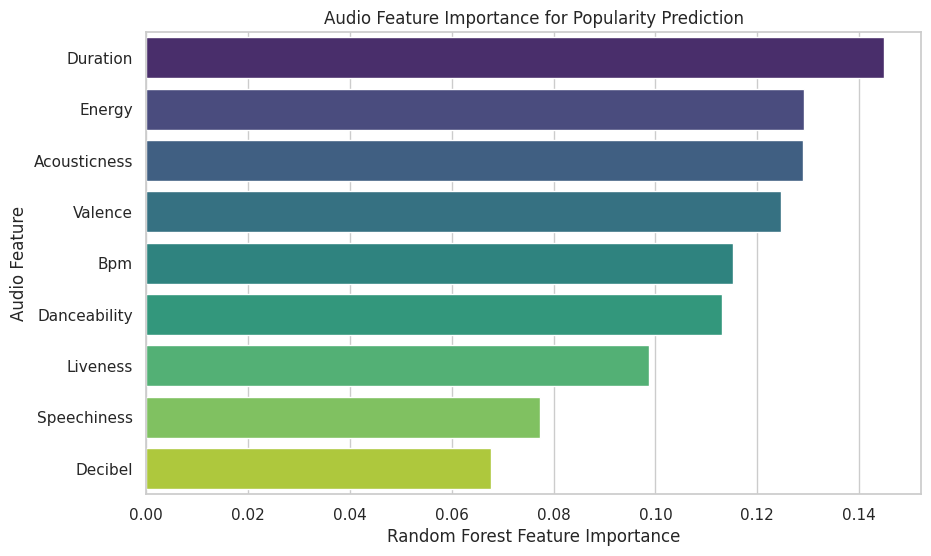

In [30]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=audio_feature_importance,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.title("Audio Feature Importance for Popularity Prediction")
plt.xlabel("Random Forest Feature Importance")
plt.ylabel("Audio Feature")
plt.show()

### Visualize Audio Feature Importance
This cell creates a bar plot to visually represent the importance of each audio feature in the Random Forest model, helping to identify key acoustic drivers of popularity.

In [31]:
platform_features = [
    "Streams",
    "In Spotify Playlists",
    "On Spotify Charts",
    "Billboard Rankings",
    "In Apple Playlists",
    "On Apple Charts",
    "In Deezer Playlists",
    "In Deezer Charts",
    "In YouTube Playlists",
    "On Shazam Charts"
]

full_features = audio_features + platform_features

X_full = data[full_features]

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_full,
    y,
    test_size=0.20,
    random_state=42
)

### Prepare Data for Full Popularity Model (Audio + Platform)
This cell defines platform-specific features, combines them with audio features to create a full feature set, and then splits the data into training and testing sets for a more comprehensive popularity prediction model.

In [32]:
rf_full_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=12,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_full_model.fit(X_train_full, y_train_full)

rf_full_predictions = rf_full_model.predict(X_test_full)

rf_full_mae = mean_absolute_error(y_test_full, rf_full_predictions)
rf_full_rmse = np.sqrt(
    mean_squared_error(y_test_full, rf_full_predictions)
)
rf_full_r2 = r2_score(y_test_full, rf_full_predictions)

print(f"Full Model MAE: {rf_full_mae:.2f}")
print(f"Full Model RMSE: {rf_full_rmse:.2f}")
print(f"Full Model R²: {rf_full_r2:.4f}")

Full Model MAE: 2.85
Full Model RMSE: 5.12
Full Model R²: 0.8801


### Train and Evaluate Random Forest Model (Full Features)
This cell trains a Random Forest Regressor using both audio and platform features and evaluates its performance with MAE, RMSE, and R² metrics.

In [33]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression (Audio Only)",
        "Random Forest (Audio Only)",
        "Random Forest (Audio + Platform Metrics)"
    ],
    "MAE": [linear_mae, rf_audio_mae, rf_full_mae],
    "RMSE": [linear_rmse, rf_audio_rmse, rf_full_rmse],
    "R2 Score": [linear_r2, rf_audio_r2, rf_full_r2]
})

display(model_comparison)

,Model,MAE,RMSE,R2 Score
0,Linear Regression (Audio Only),11.234340,14.953943,-0.021917
1,Random Forest (Audio Only),10.941780,14.737699,0.007424
2,Random Forest (Audio + Platform Metrics),2.846344,5.121328,0.880141


### Compare All Model Performances
This cell updates the model comparison DataFrame to include the performance metrics of the Random Forest model trained with both audio and platform features, allowing for a comprehensive comparison across all models.

In [34]:
full_feature_importance = pd.DataFrame({
    "Feature": full_features,
    "Importance": rf_full_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

display(full_feature_importance)

,Feature,Importance
10,In Spotify Playlists,0.660079
9,Streams,0.245000
11,On Spotify Charts,0.020580
16,In Deezer Charts,0.010604
18,On Shazam Charts,0.009669
0,Bpm,0.008556
13,In Apple Playlists,0.006859
14,On Apple Charts,0.006547
17,In YouTube Playlists,0.004454
15,In Deezer Playlists,0.004271


### Calculate Full Feature Importance
This cell calculates and displays the feature importance for the Random Forest model trained on the full set of audio and platform features.

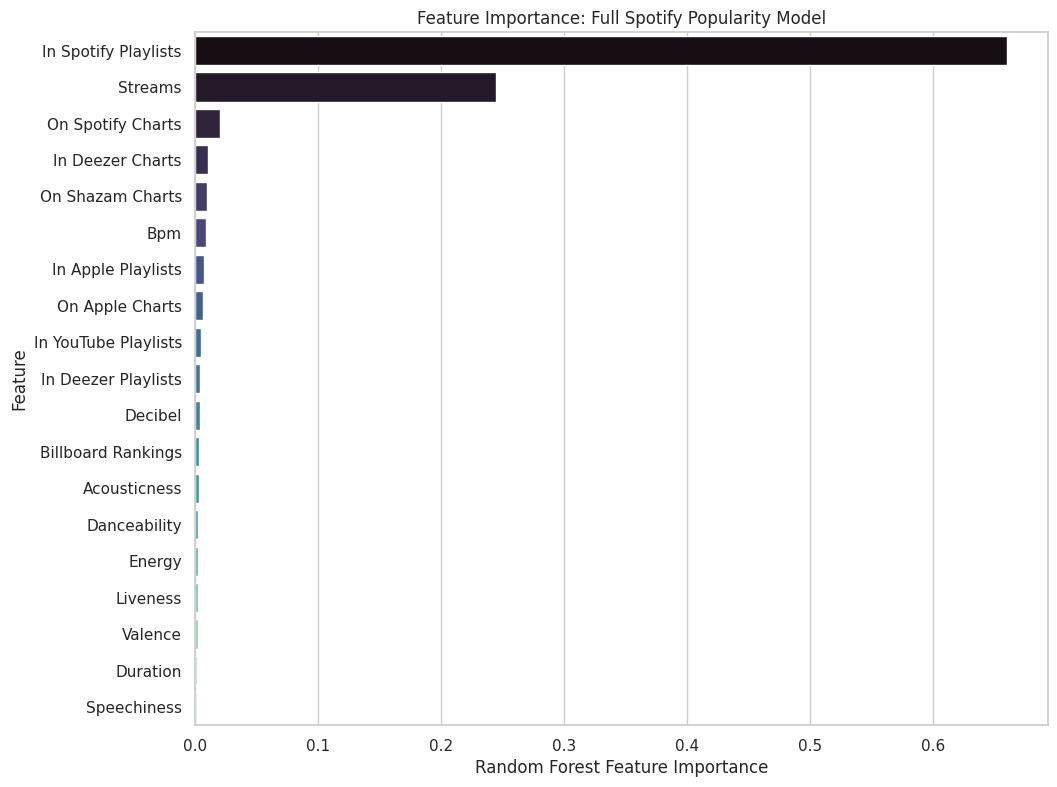

In [35]:
plt.figure(figsize=(11, 9))

sns.barplot(
    data=full_feature_importance,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="mako",
    legend=False
)

plt.title("Feature Importance: Full Spotify Popularity Model")
plt.xlabel("Random Forest Feature Importance")
plt.ylabel("Feature")
plt.show()

### Visualize Full Feature Importance
This cell generates a bar plot to visualize the importance of all features (audio and platform) in the Random Forest model, highlighting the most significant predictors of song popularity.

In [37]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scaler = StandardScaler()

X_cluster = scaler.fit_transform(data[audio_features])

### Prepare Data for K-Means Clustering
This cell initializes a StandardScaler and scales the audio features, preparing the data for K-Means clustering analysis. Scaling is crucial for distance-based algorithms like K-Means.

In [38]:
results = []

for k in range(2, 9):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_cluster)

    results.append({
        "Clusters": k,
        "Inertia": kmeans.inertia_,
        "Silhouette Score": silhouette_score(X_cluster, labels)
    })

cluster_evaluation = pd.DataFrame(results)

display(cluster_evaluation)

,Clusters,Inertia,Silhouette Score
0,2,4409.049197,0.267895
1,3,3936.780571,0.155901
2,4,3583.065764,0.158151
3,5,3287.267250,0.149277
4,6,3057.638601,0.150944
5,7,2902.444364,0.128080
6,8,2750.680825,0.133275


### Evaluate K-Means Clustering for Optimal K
This cell performs K-Means clustering for a range of cluster numbers (k) and calculates the inertia and silhouette score for each, which are used to determine the optimal number of clusters.

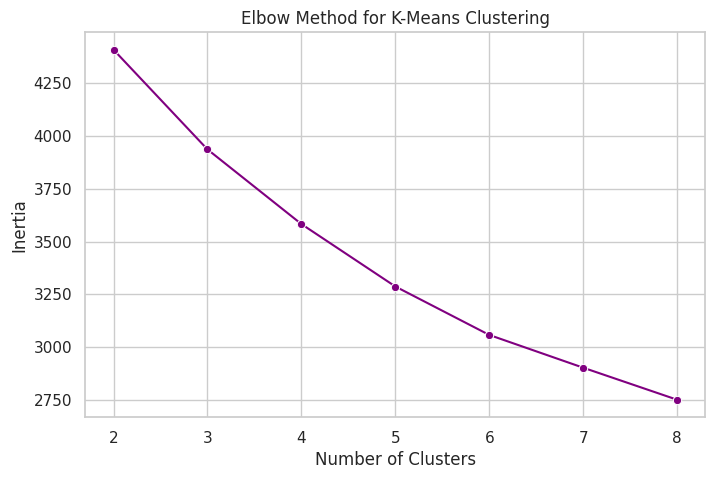

In [39]:
plt.figure(figsize=(8, 5))

sns.lineplot(
    data=cluster_evaluation,
    x="Clusters",
    y="Inertia",
    marker="o",
    color="purple"
)

plt.title("Elbow Method for K-Means Clustering")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.xticks(range(2, 9))
plt.show()

### Visualize Elbow Method for Optimal K
This cell plots the inertia values against the number of clusters (k) to apply the Elbow Method, helping to visually identify the optimal 'k' where the decrease in inertia starts to slow down.

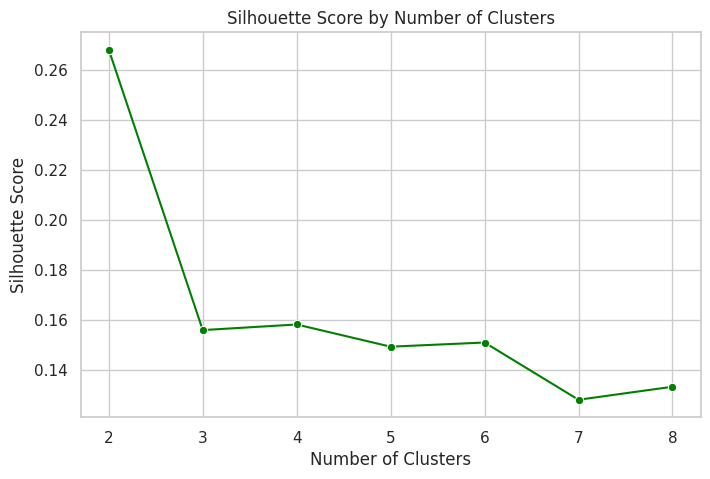

In [40]:
plt.figure(figsize=(8, 5))

sns.lineplot(
    data=cluster_evaluation,
    x="Clusters",
    y="Silhouette Score",
    marker="o",
    color="green"
)

plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.xticks(range(2, 9))
plt.show()

### Visualize Silhouette Scores for Optimal K
This cell plots the silhouette scores against the number of clusters (k), providing another metric to determine the optimal 'k' based on how well objects are clustered with similar objects compared to other clusters.

In [41]:
optimal_k = 4

final_kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

data["Cluster"] = final_kmeans.fit_predict(X_cluster)

print(data["Cluster"].value_counts().sort_index())

Cluster
0    205
1    292
2     45
3     57
Name: count, dtype: int64


In [42]:
optimal_k = 4

final_kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

data["Cluster"] = final_kmeans.fit_predict(X_cluster)

print(data["Cluster"].value_counts().sort_index())

Cluster
0    205
1    292
2     45
3     57
Name: count, dtype: int64


### Perform Final K-Means Clustering
This cell applies K-Means clustering with the chosen optimal number of clusters (k=4) to the scaled audio features and assigns a 'Cluster' label to each song in the original DataFrame.

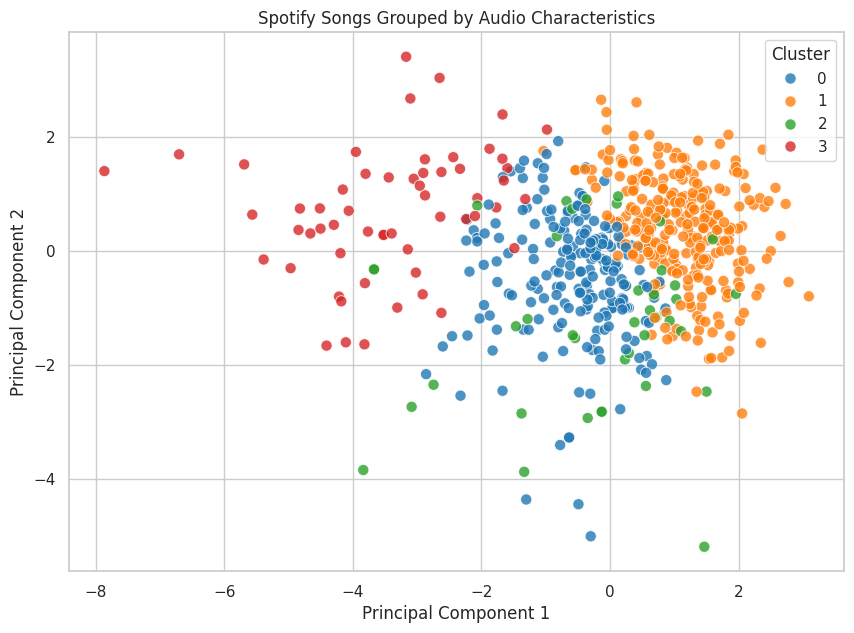

In [43]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)

pca_result = pca.fit_transform(X_cluster)

data["PCA_1"] = pca_result[:, 0]
data["PCA_2"] = pca_result[:, 1]

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=data,
    x="PCA_1",
    y="PCA_2",
    hue="Cluster",
    palette="tab10",
    s=65,
    alpha=0.8
)

plt.title("Spotify Songs Grouped by Audio Characteristics")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

### Visualize Song Clusters with PCA
This cell uses Principal Component Analysis (PCA) to reduce the dimensionality of the audio features to 2 components and then visualizes the song clusters in a 2D scatter plot, helping to understand the separation of the clusters.

In [46]:
import joblib

data.to_csv("cleaned_spotify_song_data.csv", index=False)

model_comparison.to_csv("model_comparison.csv", index=False)

audio_feature_importance.to_csv(
    "audio_feature_importance.csv",
    index=False
)

full_feature_importance.to_csv(
    "full_feature_importance.csv",
    index=False
)

# Define cluster_profile by grouping data by 'Cluster' and getting mean of audio features
cluster_profile = (
    data.groupby("Cluster")[audio_features].mean().reset_index()
)
cluster_profile.to_csv("song_cluster_profiles.csv", index=False)

joblib.dump(
    rf_audio_model,
    "spotify_audio_popularity_model.pkl"
)

joblib.dump(
    rf_full_model,
    "spotify_full_popularity_model.pkl"
)

print("All outputs have been saved successfully.")

All outputs have been saved successfully.


### Save All Processed Data and Models
This cell saves all the processed DataFrames (cleaned data, model comparisons, feature importances, cluster profiles) and trained machine learning models (Random Forest) to CSV and PKL files, respectively, for future use.

In [47]:
from google.colab import files

files.download("cleaned_spotify_song_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Download Cleaned Spotify Song Data
This cell provides a functionality to download the `cleaned_spotify_song_data.csv` file directly from the Colab environment to your local machine.

In [48]:
!pip install -q requests beautifulsoup4 lxml pandas

### Install Web Scraping Libraries
This cell installs necessary Python libraries (`requests`, `beautifulsoup4`, `lxml`, `pandas`) required for web scraping tasks.

In [49]:
import time
import requests
import pandas as pd

from bs4 import BeautifulSoup
from urllib.parse import urljoin

### Import Web Scraping Libraries
This cell imports all the required Python libraries for web scraping, including `time`, `requests`, `pandas`, `BeautifulSoup`, and `urljoin`.

In [50]:
url = "https://books.toscrape.com/"

headers = {
    "User-Agent": "Mozilla/5.0 (Educational web-scraping project)"
}

response = requests.get(url, headers=headers, timeout=20)

print("Status code:", response.status_code)

soup = BeautifulSoup(response.content, "html.parser")

books = soup.select("article.product_pod")

print("Books found on this page:", len(books))

print(books[0].get_text(" ", strip=True))

Status code: 200
Books found on this page: 20
A Light in the ... £51.77 In stock Add to basket


### Initial Web Scraping Test (Books)
This cell performs an initial HTTP GET request to `books.toscrape.com`, parses the HTML content, and extracts information about the first few books to confirm the basic web scraping setup is working.

In [51]:
def get_rating(book_card):
    rating_tag = book_card.select_one("p.star-rating")

    if rating_tag is None:
        return None

    classes = rating_tag.get("class", [])

    for rating in ["One", "Two", "Three", "Four", "Five"]:
        if rating in classes:
            return rating

    return None


def scrape_book_page(page_url):
    response = requests.get(
        page_url,
        headers=headers,
        timeout=20
    )

    response.raise_for_status()

    soup = BeautifulSoup(response.content, "html.parser")

    page_books = []

    for book in soup.select("article.product_pod"):
        title_tag = book.select_one("h3 a")
        price_tag = book.select_one("p.price_color")
        availability_tag = book.select_one("p.instock.availability")

        title = title_tag.get("title", "").strip()
        book_url = urljoin(page_url, title_tag.get("href", ""))
        price = price_tag.get_text(strip=True)
        availability = availability_tag.get_text(" ", strip=True)
        rating = get_rating(book)

        page_books.append({
            "title": title,
            "price": price,
            "availability": availability,
            "rating": rating,
            "book_url": book_url
        })

    return page_books

### Define Web Scraping Helper Functions
This cell defines two helper functions: `get_rating` to extract star ratings from book cards and `scrape_book_page` to extract detailed information (title, price, availability, rating, URL) for all books on a given page.

In [52]:
test_books = scrape_book_page("https://books.toscrape.com/")

print("Books extracted:", len(test_books))
pd.DataFrame(test_books).head()

Books extracted: 20


,title,price,availability,rating,book_url
0,A Light in the Attic,£51.77,In stock,Three,https://books.toscrape.com/catalogue/a-light-i...
1,Tipping the Velvet,£53.74,In stock,One,https://books.toscrape.com/catalogue/tipping-t...
2,Soumission,£50.10,In stock,One,https://books.toscrape.com/catalogue/soumissio...
3,Sharp Objects,£47.82,In stock,Four,https://books.toscrape.com/catalogue/sharp-obj...
4,Sapiens: A Brief History of Humankind,£54.23,In stock,Five,https://books.toscrape.com/catalogue/sapiens-a...


### Test Book Scraping Function
This cell tests the `scrape_book_page` function by applying it to the initial URL and displaying the extracted book data in a Pandas DataFrame, ensuring the function works as expected.

In [53]:
all_books = []

current_url = "https://books.toscrape.com/"

while current_url:
    print("Scraping:", current_url)

    page_books = scrape_book_page(current_url)
    all_books.extend(page_books)

    response = requests.get(
        current_url,
        headers=headers,
        timeout=20
    )

    soup = BeautifulSoup(response.content, "html.parser")

    next_button = soup.select_one("li.next a")

    if next_button:
        current_url = urljoin(
            current_url,
            next_button.get("href")
        )
    else:
        current_url = None

    time.sleep(1)

print("Total books scraped:", len(all_books))

Scraping: https://books.toscrape.com/
Scraping: https://books.toscrape.com/catalogue/page-2.html
Scraping: https://books.toscrape.com/catalogue/page-3.html
Scraping: https://books.toscrape.com/catalogue/page-4.html
Scraping: https://books.toscrape.com/catalogue/page-5.html
Scraping: https://books.toscrape.com/catalogue/page-6.html
Scraping: https://books.toscrape.com/catalogue/page-7.html
Scraping: https://books.toscrape.com/catalogue/page-8.html
Scraping: https://books.toscrape.com/catalogue/page-9.html
Scraping: https://books.toscrape.com/catalogue/page-10.html
Scraping: https://books.toscrape.com/catalogue/page-11.html
Scraping: https://books.toscrape.com/catalogue/page-12.html
Scraping: https://books.toscrape.com/catalogue/page-13.html
Scraping: https://books.toscrape.com/catalogue/page-14.html
Scraping: https://books.toscrape.com/catalogue/page-15.html
Scraping: https://books.toscrape.com/catalogue/page-16.html
Scraping: https://books.toscrape.com/catalogue/page-17.html
Scraping: 

### Scrape All Books from Website
This cell iteratively scrapes data from all pages of `books.toscrape.com` using a `while` loop and the `scrape_book_page` function, collecting information about all available books.

In [54]:
books_df = pd.DataFrame(all_books)

books_df.head()

,title,price,availability,rating,book_url
0,A Light in the Attic,£51.77,In stock,Three,https://books.toscrape.com/catalogue/a-light-i...
1,Tipping the Velvet,£53.74,In stock,One,https://books.toscrape.com/catalogue/tipping-t...
2,Soumission,£50.10,In stock,One,https://books.toscrape.com/catalogue/soumissio...
3,Sharp Objects,£47.82,In stock,Four,https://books.toscrape.com/catalogue/sharp-obj...
4,Sapiens: A Brief History of Humankind,£54.23,In stock,Five,https://books.toscrape.com/catalogue/sapiens-a...


### Create DataFrame from Scraped Books
This cell converts the list of scraped book data into a Pandas DataFrame and displays its head, organizing the collected information into a structured format.

In [55]:
books_df["price_gbp"] = (
    books_df["price"]
    .str.replace("£", "", regex=False)
    .astype(float)
)

rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

books_df["rating_number"] = books_df["rating"].map(rating_map)

books_df["in_stock"] = books_df["availability"].str.contains(
    "In stock",
    case=False,
    na=False
)

books_df = books_df.drop_duplicates(
    subset=["title", "book_url"]
).reset_index(drop=True)

print("Dataset shape:", books_df.shape)

print("\nMissing values:")
print(books_df.isnull().sum())

display(books_df.head())

Dataset shape: (1000, 8)

Missing values:
title            0
price            0
availability     0
rating           0
book_url         0
price_gbp        0
rating_number    0
in_stock         0
dtype: int64


,title,price,availability,rating,book_url,price_gbp,rating_number,in_stock
0,A Light in the Attic,£51.77,In stock,Three,https://books.toscrape.com/catalogue/a-light-i...,51.77,3,True
1,Tipping the Velvet,£53.74,In stock,One,https://books.toscrape.com/catalogue/tipping-t...,53.74,1,True
2,Soumission,£50.10,In stock,One,https://books.toscrape.com/catalogue/soumissio...,50.10,1,True
3,Sharp Objects,£47.82,In stock,Four,https://books.toscrape.com/catalogue/sharp-obj...,47.82,4,True
4,Sapiens: A Brief History of Humankind,£54.23,In stock,Five,https://books.toscrape.com/catalogue/sapiens-a...,54.23,5,True


### Clean and Preprocess Scraped Book Data
This cell cleans and preprocesses the scraped book data by converting price to a numeric format, mapping star ratings to numerical values, creating a boolean 'in_stock' column, and removing duplicate entries.

In [56]:
books_df.to_csv(
    "scraped_books_dataset.csv",
    index=False
)

print("Dataset saved successfully.")

Dataset saved successfully.


### Save Scraped Books Dataset
This cell saves the cleaned and processed `books_df` DataFrame to a CSV file named `scraped_books_dataset.csv` for persistent storage and future analysis.

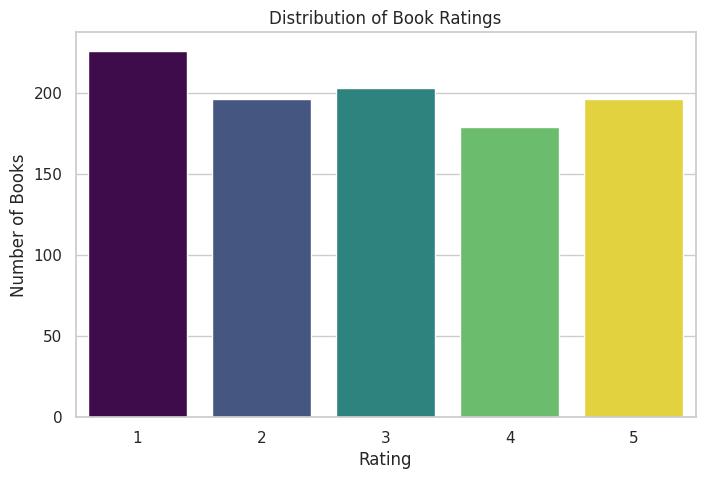

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.countplot(
    data=books_df,
    x="rating_number",
    hue="rating_number",
    palette="viridis",
    legend=False
)

plt.title("Distribution of Book Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Books")
plt.show()

### Visualize Distribution of Book Ratings
This cell generates a count plot to visualize the distribution of book ratings, showing how many books fall into each star rating category.

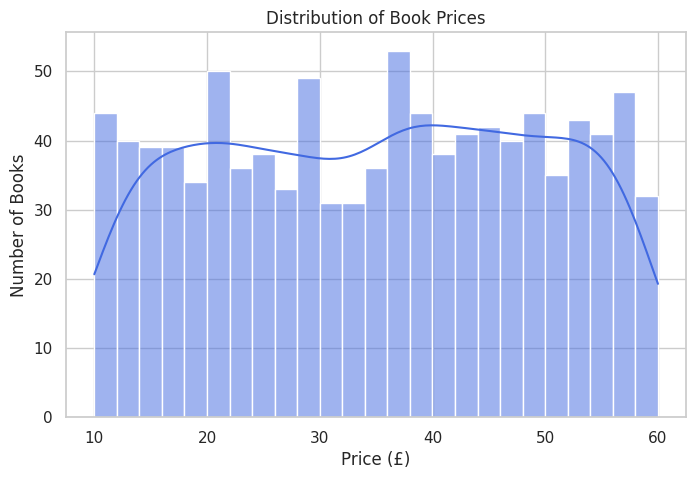

In [58]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=books_df,
    x="price_gbp",
    bins=25,
    kde=True,
    color="royalblue"
)

plt.title("Distribution of Book Prices")
plt.xlabel("Price (£)")
plt.ylabel("Number of Books")
plt.show()

### Visualize Distribution of Book Prices
This cell creates a histogram with a kernel density estimate (KDE) to visualize the distribution of book prices, providing insights into the price range and density of books.

In [59]:
books_df.sort_values(
    by="price_gbp",
    ascending=False
)[["title", "price_gbp", "rating_number", "availability"]].head(10)

,title,price_gbp,rating_number,availability
648,The Perfect Play (Play by Play #1),59.99,3,In stock
617,Last One Home (New Beginnings #1),59.98,3,In stock
860,Civilization and Its Discontents,59.95,2,In stock
560,The Barefoot Contessa Cookbook,59.92,5,In stock
366,The Diary of a Young Girl,59.90,3,In stock
657,The Bone Hunters (Lexy Vaughan & Steven Macaul...,59.71,3,In stock
133,Thomas Jefferson and the Tripoli Pirates: The ...,59.64,1,In stock
387,Boar Island (Anna Pigeon #19),59.48,3,In stock
549,The Man Who Mistook His Wife for a Hat and Oth...,59.45,4,In stock
393,The Improbability of Love,59.45,1,In stock


### Display Top 10 Most Expensive Books
This cell sorts the `books_df` DataFrame by price in descending order and displays the top 10 most expensive books along with their titles, prices, ratings, and availability.

In [60]:
import requests
import pandas as pd
from bs4 import BeautifulSoup

url = "https://quotes.toscrape.com/"

response = requests.get(url, timeout=20)
soup = BeautifulSoup(response.content, "html.parser")

quotes_data = []

for quote in soup.select("div.quote"):
    quotes_data.append({
        "quote": quote.select_one("span.text").get_text(strip=True),
        "author": quote.select_one("small.author").get_text(strip=True),
        "tags": ", ".join(
            tag.get_text(strip=True)
            for tag in quote.select("div.tags a.tag")
        )
    })

quotes_df = pd.DataFrame(quotes_data)

display(quotes_df.head())

quotes_df.to_csv("scraped_quotes.csv", index=False)

,quote,author,tags
0,“The world as we have created it is a process ...,Albert Einstein,"change, deep-thoughts, thinking, world"
1,"“It is our choices, Harry, that show what we t...",J.K. Rowling,"abilities, choices"
2,“There are only two ways to live your life. On...,Albert Einstein,"inspirational, life, live, miracle, miracles"
3,"“The person, be it gentleman or lady, who has ...",Jane Austen,"aliteracy, books, classic, humor"
4,"“Imperfection is beauty, madness is genius and...",Marilyn Monroe,"be-yourself, inspirational"


### Scrape Quotes from Quotes to Scrape
This cell scrapes quotes, authors, and tags from `quotes.toscrape.com`, stores them in a DataFrame, and saves the data to a CSV file.

In [61]:
import time
import requests
import pandas as pd

from bs4 import BeautifulSoup
from urllib.parse import urljoin

BASE_URL = "https://example.com"

headers = {
    "User-Agent": "Mozilla/5.0 (Educational research project)"
}

response = requests.get(
    BASE_URL,
    headers=headers,
    timeout=20
)

response.raise_for_status()

soup = BeautifulSoup(response.content, "html.parser")

records = []

for card in soup.select(".item-card"):
    title_tag = card.select_one(".title")
    price_tag = card.select_one(".price")

    records.append({
        "title": title_tag.get_text(" ", strip=True) if title_tag else None,
        "price": price_tag.get_text(" ", strip=True) if price_tag else None
    })

    time.sleep(0.5)

scraped_df = pd.DataFrame(records)

scraped_df.to_csv("scraped_data.csv", index=False)

display(scraped_df.head())

""


### Scrape Data from Example Website
This cell provides a generic web scraping example for `example.com`, extracting titles and prices from 'item-card' elements, and saving the results to `scraped_data.csv`.

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")

print("Dataset shape:", books_df.shape)
print("\nColumns:", books_df.columns.tolist())

display(books_df.head())

print("\nMissing values:")
print(books_df.isnull().sum())

print("\nSummary statistics:")
display(books_df[["price_gbp", "rating_number"]].describe())

Dataset shape: (1000, 8)

Columns: ['title', 'price', 'availability', 'rating', 'book_url', 'price_gbp', 'rating_number', 'in_stock']


,title,price,availability,rating,book_url,price_gbp,rating_number,in_stock
0,A Light in the Attic,£51.77,In stock,Three,https://books.toscrape.com/catalogue/a-light-i...,51.77,3,True
1,Tipping the Velvet,£53.74,In stock,One,https://books.toscrape.com/catalogue/tipping-t...,53.74,1,True
2,Soumission,£50.10,In stock,One,https://books.toscrape.com/catalogue/soumissio...,50.10,1,True
3,Sharp Objects,£47.82,In stock,Four,https://books.toscrape.com/catalogue/sharp-obj...,47.82,4,True
4,Sapiens: A Brief History of Humankind,£54.23,In stock,Five,https://books.toscrape.com/catalogue/sapiens-a...,54.23,5,True



Missing values:
title            0
price            0
availability     0
rating           0
book_url         0
price_gbp        0
rating_number    0
in_stock         0
dtype: int64

Summary statistics:


,price_gbp,rating_number
count,1000.00000,1000.000000
mean,35.07035,2.923000
std,14.44669,1.434967
min,10.00000,1.000000
25%,22.10750,2.000000
50%,35.98000,3.000000
75%,47.45750,4.000000
max,59.99000,5.000000


### Initial Exploratory Data Analysis of Scraped Books
This cell performs an initial EDA on the `books_df`, including checking its shape, columns, displaying the head, identifying missing values, and generating summary statistics for numeric columns.

In [63]:
books_df["price_gbp"] = (
    books_df["price"]
    .astype(str)
    .str.replace("£", "", regex=False)
    .astype(float)
)

rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

books_df["rating_number"] = books_df["rating"].map(rating_map)

### Re-process Price and Rating Columns for Scraped Books
This cell re-processes the 'price' and 'rating' columns in `books_df`, converting 'price' to a numeric 'price_gbp' and mapping 'rating' strings to numeric 'rating_number'. This ensures these columns are in the correct format for quantitative analysis.

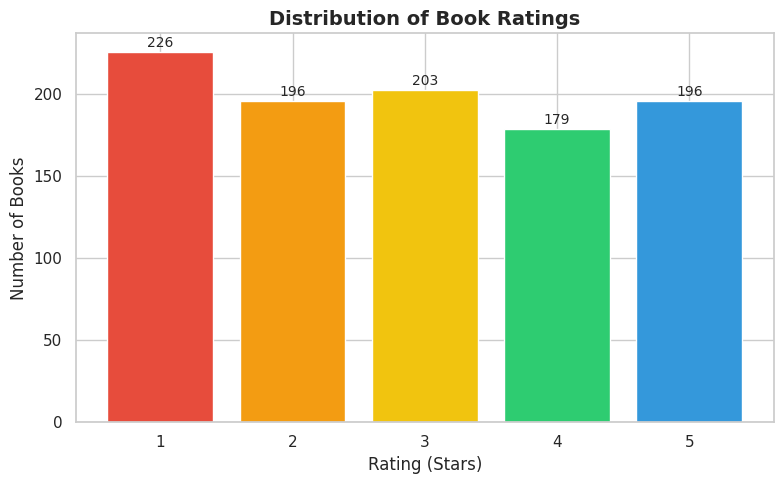

In [64]:
rating_counts = (
    books_df["rating_number"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    rating_counts.index,
    rating_counts.values,
    color=["#e74c3c", "#f39c12", "#f1c40f", "#2ecc71", "#3498db"]
)

plt.title("Distribution of Book Ratings", fontsize=14, fontweight="bold")
plt.xlabel("Rating (Stars)")
plt.ylabel("Number of Books")
plt.xticks([1, 2, 3, 4, 5])

for bar, count in zip(bars, rating_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3,
        str(count),
        ha="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

### Detailed Visualization of Book Rating Distribution
This cell generates a detailed bar chart showing the distribution of book ratings, including numerical labels on each bar for precise count visualization.

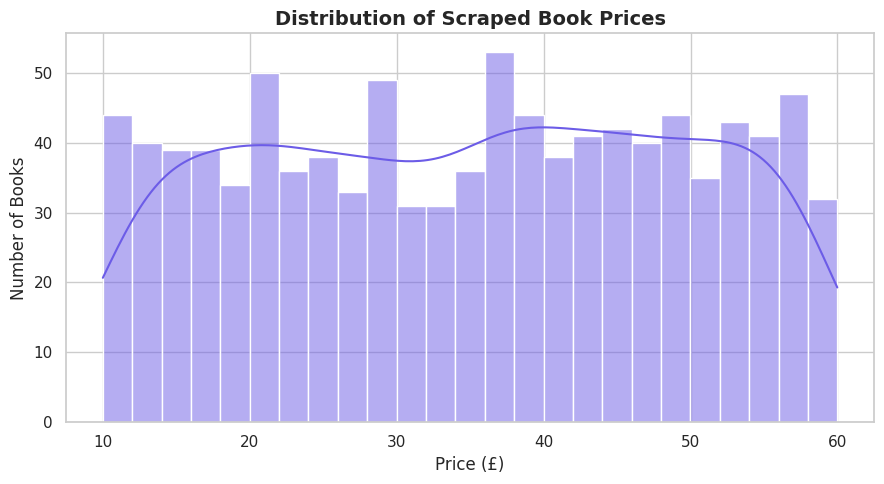

In [65]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=books_df,
    x="price_gbp",
    bins=25,
    kde=True,
    color="#6c5ce7"
)

plt.title("Distribution of Scraped Book Prices", fontsize=14, fontweight="bold")
plt.xlabel("Price (£)")
plt.ylabel("Number of Books")

plt.tight_layout()
plt.show()

### Detailed Visualization of Scraped Book Prices
This cell creates a histogram with a kernel density estimate for the `price_gbp` column, providing a clear visual representation of the distribution of scraped book prices.

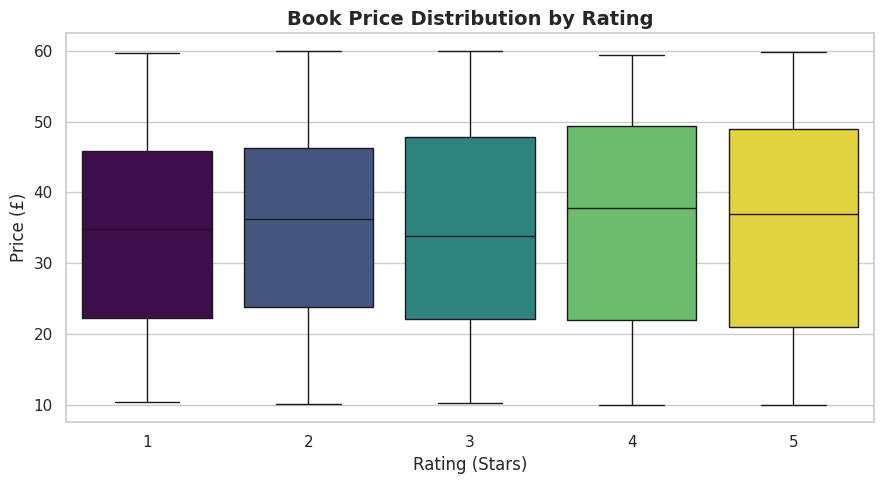

In [66]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=books_df,
    x="rating_number",
    y="price_gbp",
    hue="rating_number",
    palette="viridis",
    legend=False
)

plt.title("Book Price Distribution by Rating", fontsize=14, fontweight="bold")
plt.xlabel("Rating (Stars)")
plt.ylabel("Price (£)")

plt.tight_layout()
plt.show()

### Book Price Distribution by Rating
This cell generates a box plot to visualize the distribution of book prices across different rating categories, allowing for a comparison of price ranges based on ratings.

In [67]:
average_price_by_rating = (
    books_df.groupby("rating_number")["price_gbp"]
    .mean()
    .reset_index()
)

display(average_price_by_rating)

,rating_number,price_gbp
0,1,34.561195
1,2,34.810918
2,3,34.692020
3,4,36.093296
4,5,35.374490


### Calculate Average Price by Book Rating
This cell calculates the average price (`price_gbp`) for books in each rating category (`rating_number`) and displays the resulting table.

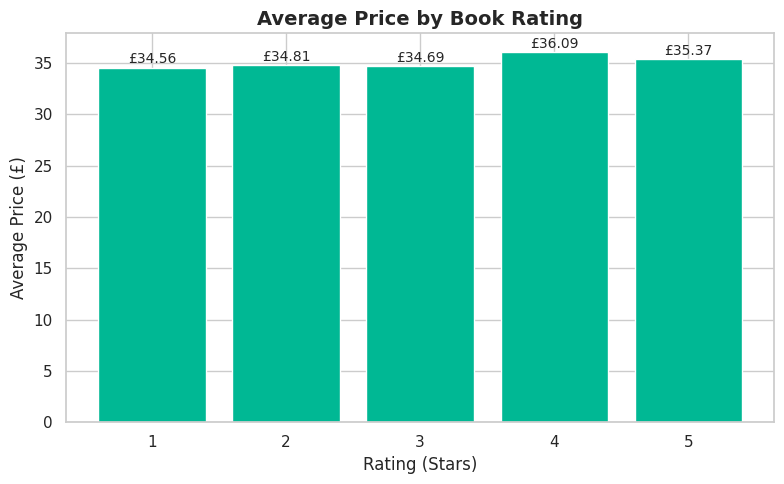

In [68]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    average_price_by_rating["rating_number"],
    average_price_by_rating["price_gbp"],
    color="#00b894"
)

plt.title("Average Price by Book Rating", fontsize=14, fontweight="bold")
plt.xlabel("Rating (Stars)")
plt.ylabel("Average Price (£)")
plt.xticks([1, 2, 3, 4, 5])

for bar, value in zip(bars, average_price_by_rating["price_gbp"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.4,
        f"£{value:.2f}",
        ha="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

### Visualize Average Price by Book Rating
This cell creates a bar chart to visualize the average price of books for each rating category, with price labels on each bar for clarity.

In [69]:
top_expensive_books = (
    books_df.sort_values("price_gbp", ascending=False)
    .head(10)
    .sort_values("price_gbp")
)

display(
    top_expensive_books[
        ["title", "price_gbp", "rating_number", "availability"]
    ]
)

,title,price_gbp,rating_number,availability
393,The Improbability of Love,59.45,1,In stock
549,The Man Who Mistook His Wife for a Hat and Oth...,59.45,4,In stock
387,Boar Island (Anna Pigeon #19),59.48,3,In stock
133,Thomas Jefferson and the Tripoli Pirates: The ...,59.64,1,In stock
657,The Bone Hunters (Lexy Vaughan & Steven Macaul...,59.71,3,In stock
366,The Diary of a Young Girl,59.90,3,In stock
560,The Barefoot Contessa Cookbook,59.92,5,In stock
860,Civilization and Its Discontents,59.95,2,In stock
617,Last One Home (New Beginnings #1),59.98,3,In stock
648,The Perfect Play (Play by Play #1),59.99,3,In stock


### Display Top 10 Most Expensive Books (Sorted)
This cell identifies and displays the top 10 most expensive books from the dataset, sorted by price in ascending order for easier visual comparison in a horizontal bar chart.

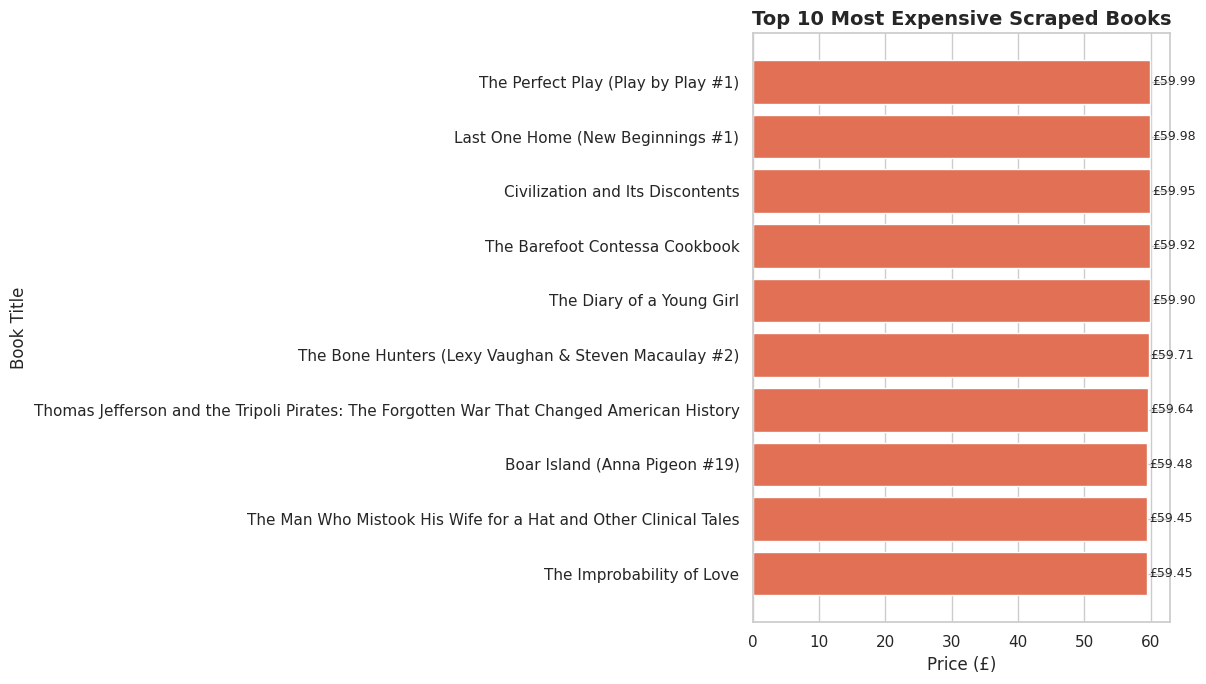

In [70]:
plt.figure(figsize=(12, 7))

plt.barh(
    top_expensive_books["title"],
    top_expensive_books["price_gbp"],
    color="#e17055"
)

plt.title("Top 10 Most Expensive Scraped Books", fontsize=14, fontweight="bold")
plt.xlabel("Price (£)")
plt.ylabel("Book Title")

for index, price in enumerate(top_expensive_books["price_gbp"]):
    plt.text(
        price + 0.3,
        index,
        f"£{price:.2f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

### Visualize Top 10 Most Expensive Books
This cell generates a horizontal bar chart to visually represent the top 10 most expensive scraped books, including their exact prices displayed on each bar.

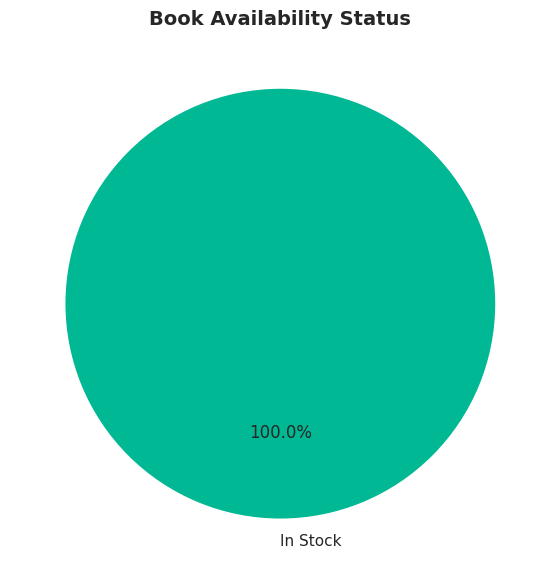

In [71]:
availability_counts = (
    books_df["in_stock"]
    .value_counts()
    .rename(index={True: "In Stock", False: "Out of Stock"})
)

plt.figure(figsize=(6, 6))

plt.pie(
    availability_counts.values,
    labels=availability_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#00b894", "#d63031"],
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)

plt.title("Book Availability Status", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Visualize Book Availability Status
This cell creates a pie chart to show the distribution of book availability (In Stock vs. Out of Stock), providing a quick overview of inventory status.

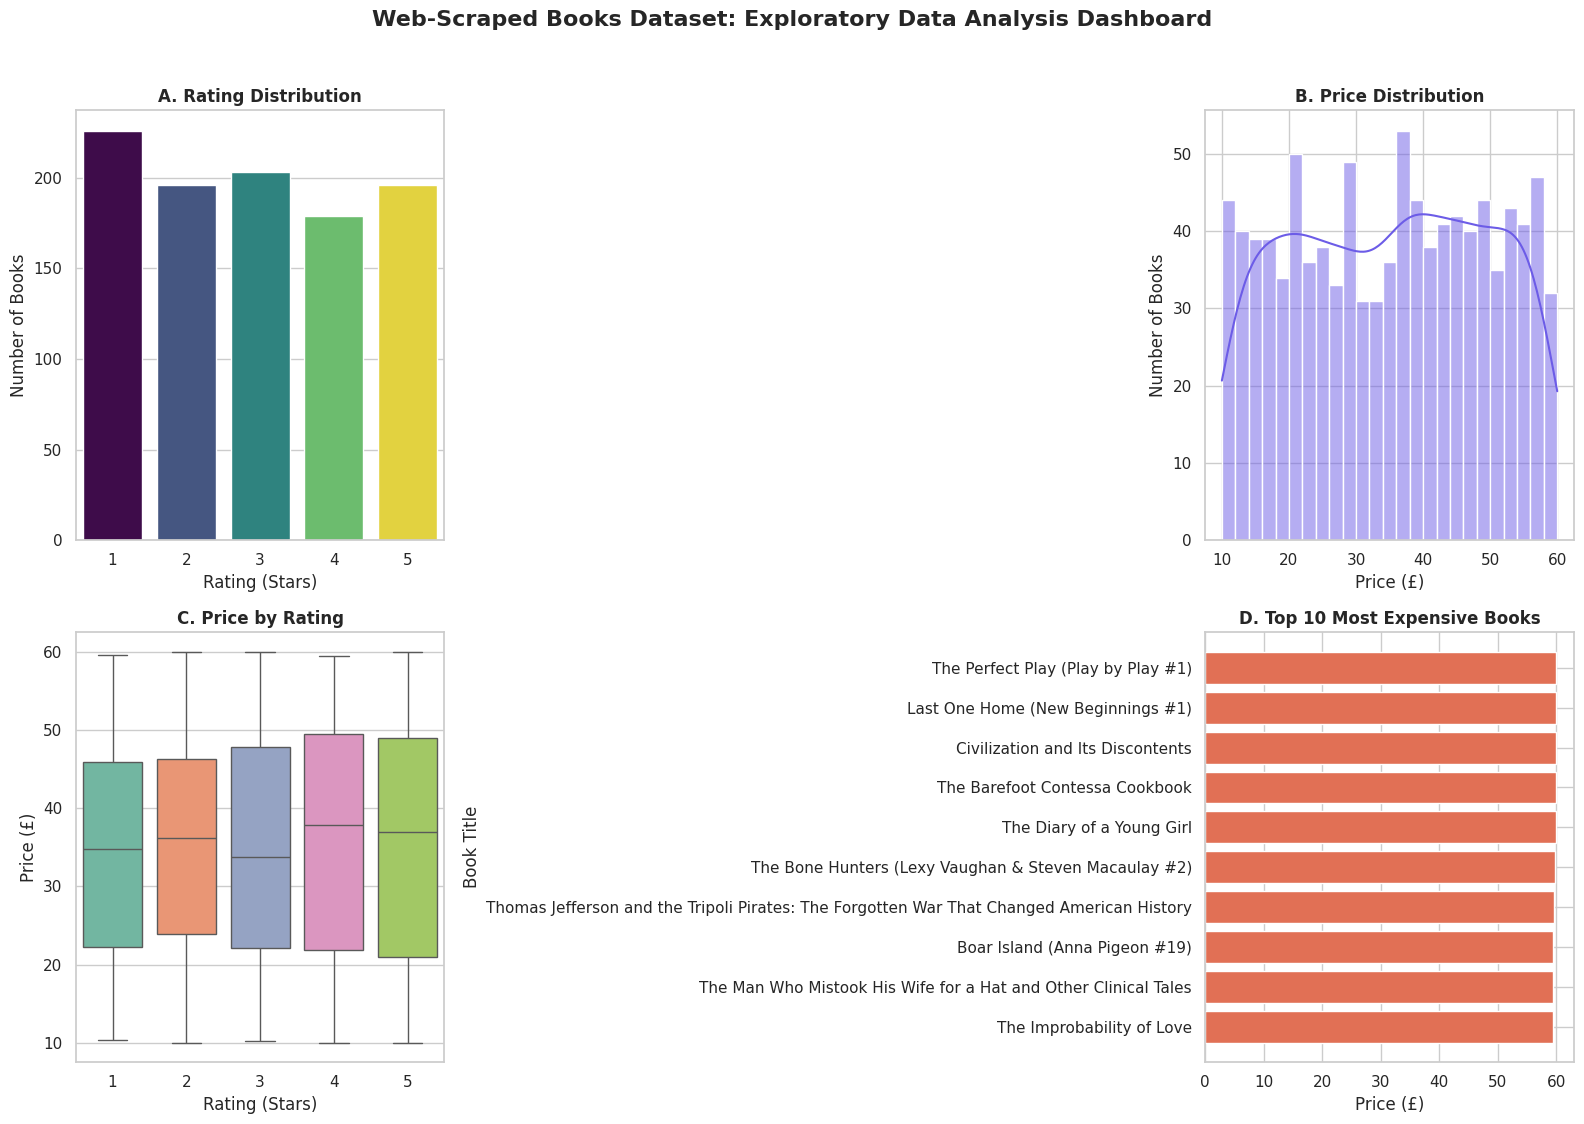

In [72]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

sns.countplot(
    data=books_df,
    x="rating_number",
    hue="rating_number",
    palette="viridis",
    legend=False,
    ax=axes[0, 0]
)

axes[0, 0].set_title("A. Rating Distribution", fontweight="bold")
axes[0, 0].set_xlabel("Rating (Stars)")
axes[0, 0].set_ylabel("Number of Books")

sns.histplot(
    data=books_df,
    x="price_gbp",
    bins=25,
    kde=True,
    color="#6c5ce7",
    ax=axes[0, 1]
)

axes[0, 1].set_title("B. Price Distribution", fontweight="bold")
axes[0, 1].set_xlabel("Price (£)")
axes[0, 1].set_ylabel("Number of Books")

sns.boxplot(
    data=books_df,
    x="rating_number",
    y="price_gbp",
    hue="rating_number",
    palette="Set2",
    legend=False,
    ax=axes[1, 0]
)

axes[1, 0].set_title("C. Price by Rating", fontweight="bold")
axes[1, 0].set_xlabel("Rating (Stars)")
axes[1, 0].set_ylabel("Price (£)")

axes[1, 1].barh(
    top_expensive_books["title"],
    top_expensive_books["price_gbp"],
    color="#e17055"
)

axes[1, 1].set_title("D. Top 10 Most Expensive Books", fontweight="bold")
axes[1, 1].set_xlabel("Price (£)")
axes[1, 1].set_ylabel("Book Title")

plt.suptitle(
    "Web-Scraped Books Dataset: Exploratory Data Analysis Dashboard",
    fontsize=16,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

### Combined EDA Dashboard for Scraped Books
This cell generates a comprehensive dashboard with four subplots, combining key visualizations such as rating distribution, price distribution, price by rating, and top 10 most expensive books, to provide a holistic view of the scraped book data.

In [73]:
fig.savefig(
    "books_scraping_eda_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

### Save EDA Dashboard Image
This cell saves the generated combined EDA dashboard figure as a high-resolution PNG image file, suitable for reports or presentations.

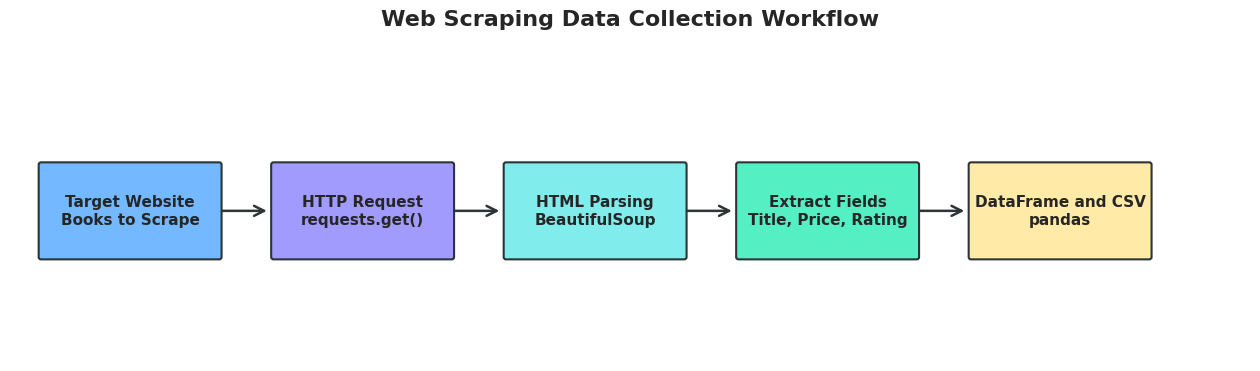

In [74]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

def add_box(ax, x, y, width, height, text, color):
    box = FancyBboxPatch(
        (x, y),
        width,
        height,
        boxstyle="round,pad=0.03",
        facecolor=color,
        edgecolor="#2d3436",
        linewidth=1.5
    )

    ax.add_patch(box)

    ax.text(
        x + width / 2,
        y + height / 2,
        text,
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        wrap=True
    )

def add_arrow(ax, x1, y1, x2, y2):
    arrow = FancyArrowPatch(
        (x1, y1),
        (x2, y2),
        arrowstyle="->",
        mutation_scale=18,
        linewidth=1.8,
        color="#2d3436"
    )

    ax.add_patch(arrow)

fig, ax = plt.subplots(figsize=(16, 4))
ax.set_xlim(0, 16)
ax.set_ylim(0, 4)
ax.axis("off")

steps = [
    (0.4, "Target Website\nBooks to Scrape", "#74b9ff"),
    (3.4, "HTTP Request\nrequests.get()", "#a29bfe"),
    (6.4, "HTML Parsing\nBeautifulSoup", "#81ecec"),
    (9.4, "Extract Fields\nTitle, Price, Rating", "#55efc4"),
    (12.4, "DataFrame and CSV\npandas", "#ffeaa7")
]

for x, text, color in steps:
    add_box(ax, x, 1.35, 2.3, 1.2, text, color)

for x in [2.7, 5.7, 8.7, 11.7]:
    add_arrow(ax, x, 1.95, x + 0.65, 1.95)

plt.title(
    "Web Scraping Data Collection Workflow",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.savefig(
    "web_scraping_workflow.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Create Web Scraping Data Collection Workflow Diagram
This cell defines functions for drawing styled boxes and arrows, then uses them to create and display a visual workflow diagram illustrating the steps involved in collecting data through web scraping.

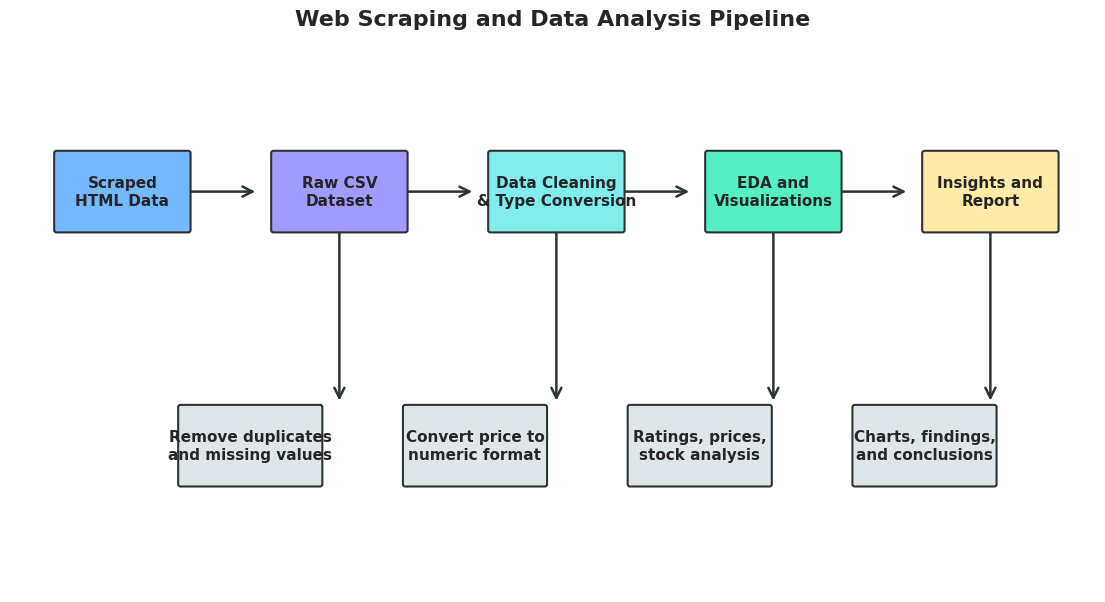

In [75]:
fig, ax = plt.subplots(figsize=(14, 7))
ax.set_xlim(0, 14)
ax.set_ylim(0, 7)
ax.axis("off")

pipeline_steps = [
    (0.6, 4.7, "Scraped\nHTML Data", "#74b9ff"),
    (3.4, 4.7, "Raw CSV\nDataset", "#a29bfe"),
    (6.2, 4.7, "Data Cleaning\n& Type Conversion", "#81ecec"),
    (9.0, 4.7, "EDA and\nVisualizations", "#55efc4"),
    (11.8, 4.7, "Insights and\nReport", "#ffeaa7")
]

for x, y, text, color in pipeline_steps:
    add_box(ax, x, y, 1.7, 1.0, text, color)

for x in [2.3, 5.1, 7.9, 10.7]:
    add_arrow(ax, x, 5.2, x + 0.9, 5.2)

analysis_steps = [
    (2.2, 1.4, "Remove duplicates\nand missing values", "#dfe6e9"),
    (5.1, 1.4, "Convert price to\nnumeric format", "#dfe6e9"),
    (8.0, 1.4, "Ratings, prices,\nstock analysis", "#dfe6e9"),
    (10.9, 1.4, "Charts, findings,\nand conclusions", "#dfe6e9")
]

for x, y, text, color in analysis_steps:
    add_box(ax, x, y, 1.8, 1.0, text, color)

for x, y in [(4.25, 4.7), (7.05, 4.7), (9.85, 4.7), (12.65, 4.7)]:
    add_arrow(ax, x, y, x, 2.45)

plt.title(
    "Web Scraping and Data Analysis Pipeline",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.savefig(
    "web_scraping_analysis_pipeline.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Create Web Scraping and Data Analysis Pipeline Diagram
This cell generates a diagram visualizing the entire pipeline from web scraping to data analysis, including steps like HTML parsing, data cleaning, EDA, and reporting. It helps illustrate the project's flow.

In [76]:
from google.colab import files

files.download("books_scraping_eda_dashboard.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Download EDA Dashboard Image
This cell allows the user to download the `books_scraping_eda_dashboard.png` image file, which contains the combined exploratory data analysis visualizations.